In [1]:
import pickle
import numpy as np
from figure import * 
import seaborn as sns
import cmasher as cmr

In [2]:
with open('./4_time_0/odr_t0_bootstrapped', 'rb') as f:
    odr_t0 = pickle.load(f)
odr_t0 = odr_t0.reshape(-1,1)

with open('./1_delta_02/odr_Cjj_bootstrapped', 'rb') as f:
    odr_cjj_02 = pickle.load(f)
odr_cjj_02 = np.concatenate((odr_t0, odr_cjj_02), axis =1 )/40

with open('./2_delta_1/odr_Cjj_bootstrapped', 'rb') as f:
    odr_cjj_1 = pickle.load(f)
odr_cjj_1 = np.concatenate((odr_t0, odr_cjj_1), axis =1 )/40

with open('./3_delta_16/odr_Cjj_bootstrapped', 'rb') as f:
    odr_cjj_16 = pickle.load(f)
odr_cjj_16 = np.concatenate((odr_t0, odr_cjj_16), axis =1 )/40

with open('5_mps/mps_02', 'rb') as f:
    mps_02 = pickle.load(f)
mps_02 = mps_02.reshape(-1, 16)

with open('5_mps/mps_1', 'rb') as f:
    mps_1 = pickle.load(f)
mps_1 = mps_1.reshape(-1, 16)
with open('5_mps/mps_16', 'rb') as f:
    mps_16 = pickle.load(f)
mps_16 = mps_16.reshape(-1, 16)

Figure 3C

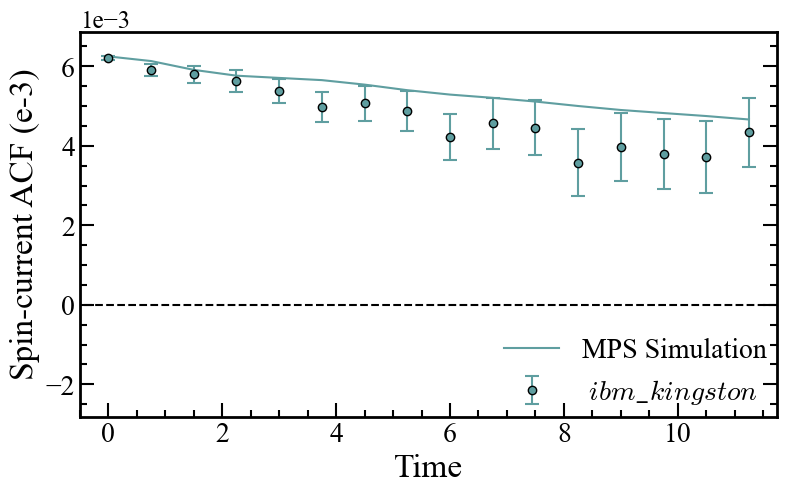

In [3]:
times = np.arange(0,0.75*(15+1),0.75)
fig, ax = plt.subplots(figsize=(9,5)) 
font25 = {'family': 'Times new roman','weight': 'normal','size': 18}
plt.rcParams['mathtext.fontset'] ='cm'  
ax.errorbar(times, np.real(np.mean(odr_cjj_02, axis=0)), yerr=2*np.std(odr_cjj_02, axis =0),
              color = 'cadetblue', capsize=5, capthick= 1.5, fmt='o',label = ' $ibm\_kingston$ ',
              markeredgecolor='black', zorder=5,)
ax.plot(times, np.real(np.sum(mps_02, axis=0))/(40), color='cadetblue', label = 'MPS Simulation')
ax.set_ylim(-0.45/(40*4), 1.1/(40*4))
ax.set_xlim(-0.5,11.75)
ax.hlines(0, -1, 13, color='black', ls='--')
adjust_ax(ax)
ax.set_xlabel('Time', font='Times new roman', fontsize=24)
ax.set_ylabel('Spin-current ACF (e-3)',  font='Times new roman', fontsize=24)
ax.ticklabel_format(axis='y', style='sci', scilimits=(-2,2))
ax.yaxis.offsetText.set_fontsize(18)
ax.yaxis.offsetText.set_fontname('Times new roman')
ax.legend(prop=font2, frameon=False, ncol=1, bbox_to_anchor=(1.02, 0.27))


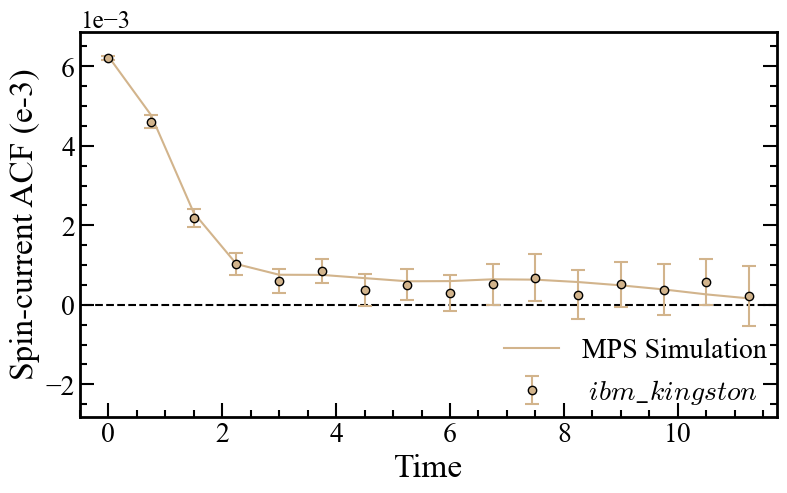

In [4]:
times = np.arange(0,0.75*(15+1),0.75)
fig, ax = plt.subplots(figsize=(9,5)) 
font25 = {'family': 'Times new roman','weight': 'normal','size': 18}
plt.rcParams['mathtext.fontset'] ='cm'  
ax.errorbar(times, np.mean(odr_cjj_1, axis=0), yerr=2*np.std(odr_cjj_1, axis =0),
              color = 'tan', capsize=5, capthick= 1.5, fmt='o',label = ' $ibm\_kingston$ ',
              markeredgecolor='black', zorder=5,)
ax.plot(times, np.real(np.sum(mps_1, axis=0))/(40), color='tan', label = 'MPS Simulation')
ax.set_ylim(-0.45/(40*4), 1.1/(40*4))
ax.set_xlim(-0.5,11.75)
ax.hlines(0, -1, 13, color='black', ls='--')
adjust_ax(ax)
ax.set_xlabel('Time', font='Times new roman', fontsize=24)
ax.set_ylabel('Spin-current ACF (e-3)',  font='Times new roman', fontsize=24)
ax.ticklabel_format(axis='y', style='sci', scilimits=(-2,2))
ax.yaxis.offsetText.set_fontsize(18)
ax.yaxis.offsetText.set_fontname('Times new roman')
ax.legend(prop=font2, frameon=False, ncol=1, bbox_to_anchor=(1.02, 0.27))


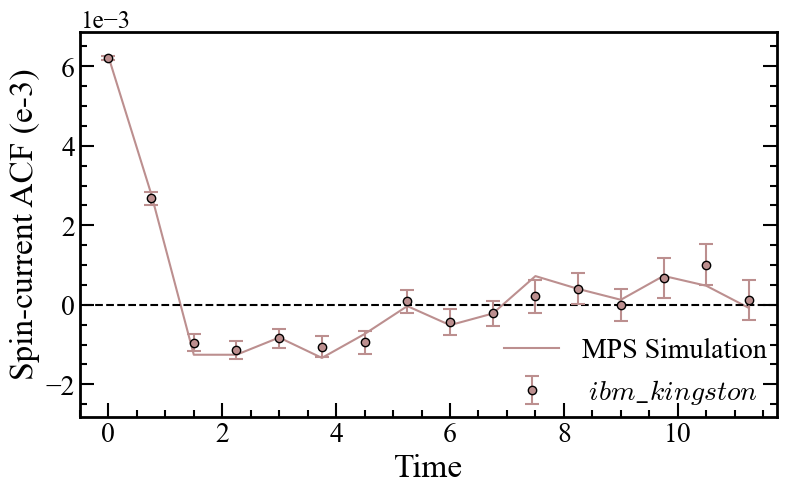

In [5]:
times = np.arange(0,0.75*(15+1),0.75)
fig, ax = plt.subplots(figsize=(9,5)) 
font25 = {'family': 'Times new roman','weight': 'normal','size': 18}
plt.rcParams['mathtext.fontset'] ='cm'  
ax.errorbar(times, np.mean(odr_cjj_16, axis=0), yerr=2*np.std(odr_cjj_16, axis =0),
              color = 'rosybrown', capsize=5, capthick= 1.5, fmt='o',label = ' $ibm\_kingston$ ',
              markeredgecolor='black', zorder=5,)
ax.plot(times, np.real(np.sum(mps_16, axis=0))/(40), color='rosybrown', label = 'MPS Simulation')
ax.set_ylim(-0.45/(40*4), 1.1/(40*4))
ax.set_xlim(-0.5,11.75)
ax.hlines(0, -1, 13, color='black', ls='--')
adjust_ax(ax)
ax.set_xlabel('Time', font='Times new roman', fontsize=24)
ax.set_ylabel('Spin-current ACF (e-3)',  font='Times new roman', fontsize=24)
ax.ticklabel_format(axis='y', style='sci', scilimits=(-2,2))
ax.yaxis.offsetText.set_fontsize(18)
ax.yaxis.offsetText.set_fontname('Times new roman')
ax.legend(prop=font2, frameon=False, ncol=1, bbox_to_anchor=(1.02, 0.27))


In [6]:
def get_total_mean_lc(lc_data, zero_data):
    n = 40 
    Total = np.zeros(shape=(n , 16))
    for i in range(100): 
        zero = np.zeros(shape=(n,1))
        zero[n//2-1] = zero_data[i]
        Total += np.concatenate((zero, lc_data[i]), axis=1)
    return Total/100


def plot_heatmap(data):
    fig, ax = plt.subplots(figsize=(6,9))
    cmap = 'cmr.fusion'
    heatmap = sns.heatmap(np.real(data[:-1,:]), center=0, cbar=False, 
            cmap=cmap, 
            vmin=-0.3/4, vmax=0.9/4, rasterized=True, )
    ax.set_xticks([])
    ax.set_yticks([])
    labels = ax.get_yticklabels() + ax.get_xticklabels()
    [label.set_fontname('Times new roman') for label in labels]
    [label.set_weight('normal') for label in labels]
    ax.tick_params(axis='y', labelsize =15, direction='out', length=8, width=1,  left=True)
    ax.tick_params(axis='x', labelsize =15, direction='out', length=8, width=1,  bottom=True)
    ax.set_xlabel('Time', font=font1, fontsize= 32)
    ax.set_ylabel('Qubit', font=font1, fontsize= 32)

    ax.hlines(0, 0,41, color='black'), ax.hlines(39, 0,41, color='black'), ax.hlines(38, 0,41, color='black'),
    ax.vlines(0, 0,41, color='black'), ax.vlines(16, 0,41, color='black')
    return heatmap

<Axes: xlabel='Time', ylabel='Qubit'>

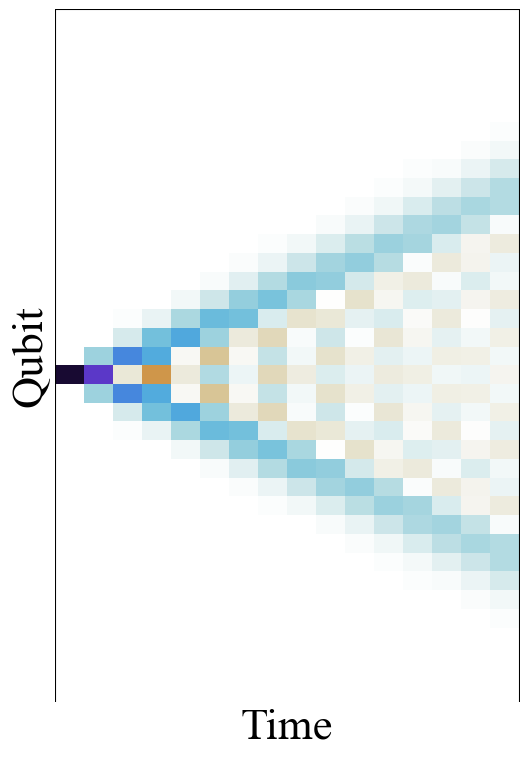

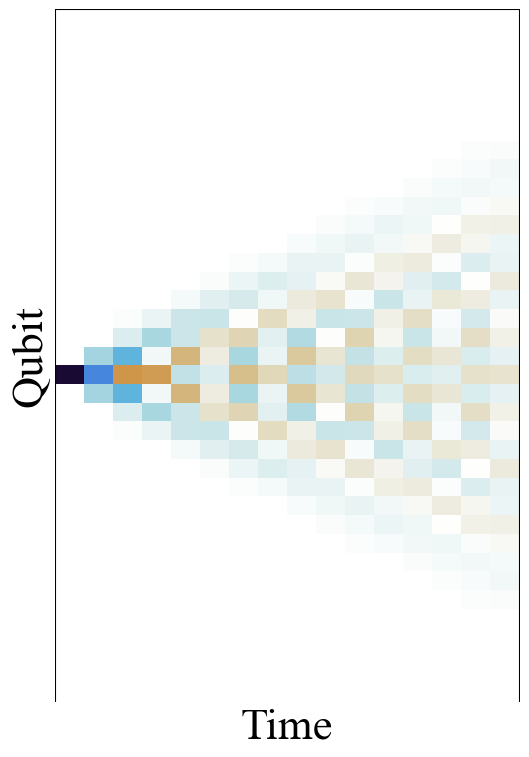

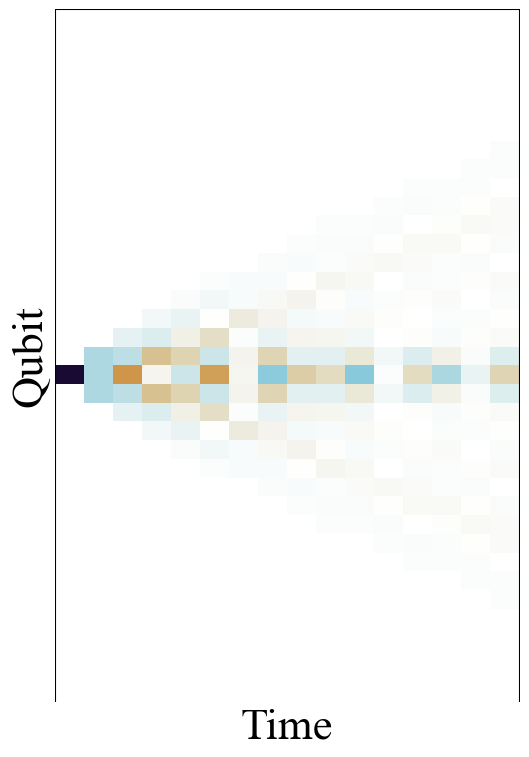

In [7]:
plot_heatmap(mps_02[:-1,:])
plot_heatmap(mps_1[:-1,:])
plot_heatmap(mps_16[:-1,:])

In [9]:

with open('./1_delta_02/odr_local_Cjj_bootstrapped', 'rb') as f:
    odr_local_cjj_02 = pickle.load(f)
odr_local_cjj_02 = get_total_mean_lc(odr_local_cjj_02, odr_t0)

with open('./2_delta_1/odr_local_Cjj_bootstrapped', 'rb') as f:
    odr_local_cjj_1 = pickle.load(f)
odr_local_cjj_1 = get_total_mean_lc(odr_local_cjj_1, odr_t0)

with open('./3_delta_16/odr_local_Cjj_bootstrapped', 'rb') as f:
    odr_local_cjj_16 = pickle.load(f)
odr_local_cjj_16 = get_total_mean_lc(odr_local_cjj_16, odr_t0)

<Axes: xlabel='Time', ylabel='Qubit'>

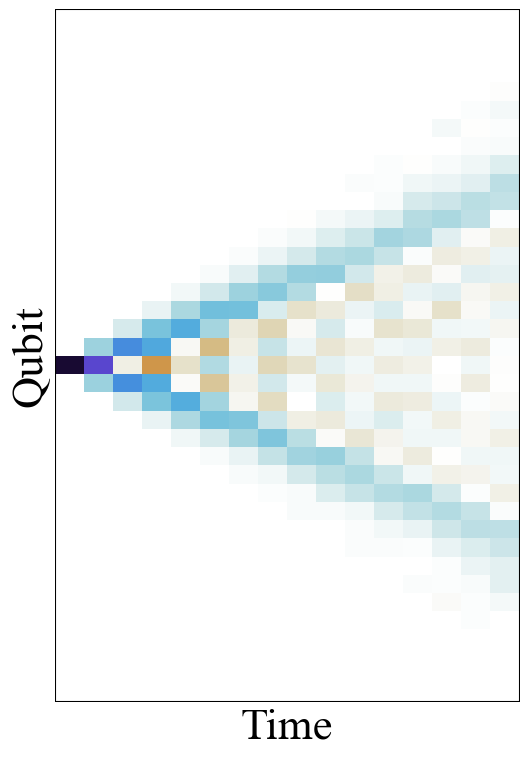

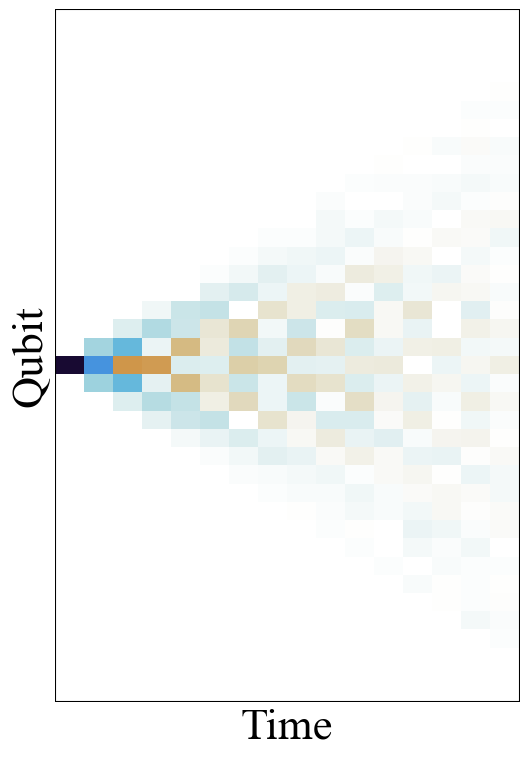

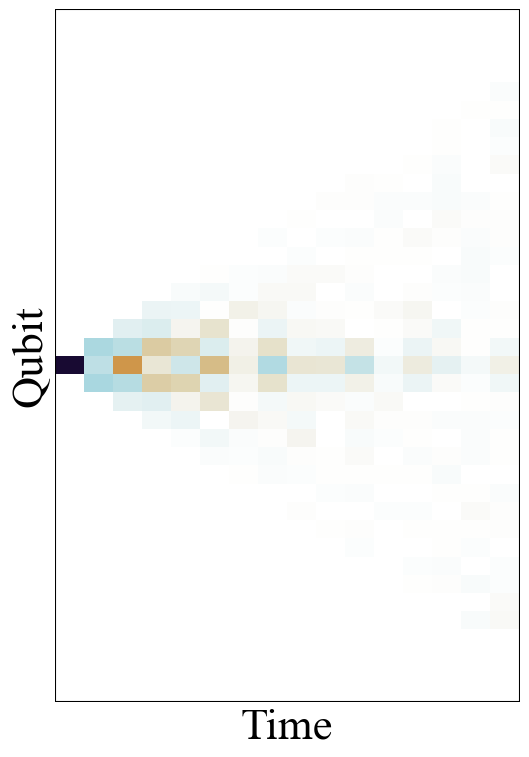

In [10]:
plot_heatmap(odr_local_cjj_02[:-1,:])
plot_heatmap(odr_local_cjj_1[:-1,:])
plot_heatmap(odr_local_cjj_16[:-1,:])

Fig. 3b


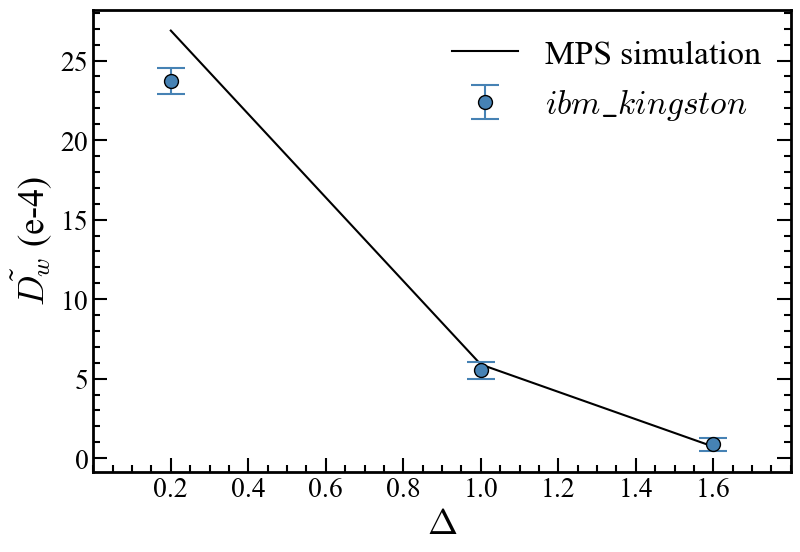

In [ ]:
# Do integration 
# expt data 
# times = np.arange(0, 0.75*16, 0.75)
# D_w = []
# for i in range(100):
#     local = np.trapz(odr_cjj_02[i], times)
#     D_w.append(local/(0.75*15*2))
# print(np.mean(D_w), np.std(D_w))

# mps
# mps_data = mps_16.reshape(-1, 16)
# mps_dw = np.trapz(np.sum(mps_data, axis=0), times)/(40*15*0.75*2)

total_drude = []
total_drude.append(0.002373869818598451), total_drude.append(0.0005520223573019221), total_drude.append(8.808440822723303e-05)
std_drude = []
std_drude.append(4.051729274599853e-05), std_drude.append(2.624356437533631e-05), std_drude.append(2.0263660823135977e-05)
mps_drude = [] 
mps_drude.append(0.002688711760021139), mps_drude.append(0.0005890957099694104), mps_drude.append(7.235429664950218e-05)
fig, ax = plt.subplots(figsize=(9, 6)) 
font25 = {'family': 'Times new roman','weight': 'normal','size': 18}
plt.rcParams['mathtext.fontset'] ='cm'  
ax.errorbar([0.2,1,1.6], np.array(total_drude)*1e+4, yerr= 2*np.array(std_drude)*1e+4,
              color = 'steelblue', capsize=10, capthick= 1.5, fmt='o',label = '$ibm\_kingston$',
              markeredgecolor='black', zorder=15, markersize= 10)
ax.plot([0.2,1,1.6], np.array(mps_drude)*1e+4, color= 'black', label='MPS simulation')
adjust_ax(ax)
ax.set_xlim(0, 1.8)
ax.set_xlabel('$ \Delta $', font='Times new roman', fontsize=26)
ax.set_ylabel('$ \\tilde{D_w} $ (e-4)',  font='Times new roman', fontsize=26)
ax.legend(prop=font1, frameon=False, ncol=1, )
ax.set_xticks(np.arange(0.2, 1.8, 0.2))

0.8243390875765927
0.015743374710095105


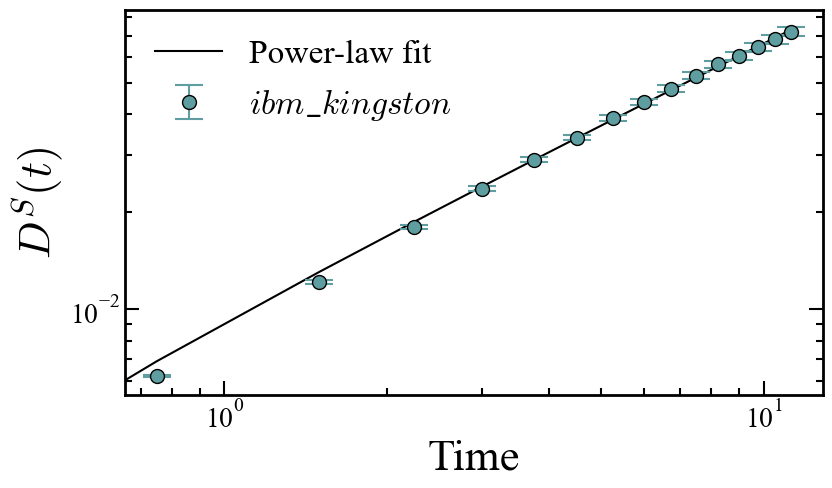

In [15]:
from scipy.optimize import curve_fit

def power(x, A, alpha, C):
    y = A*(x)**(alpha)+C
    return y

times = np.arange(0, 0.75*16, 0.75)
D_t = np.zeros(shape=(100, 16))
data = odr_cjj_02
parameters_set = []
for i in range(100):
    local = [np.sum(data[i, :j]) for j in range(16)]
    D_t[i] = local 
    parameters, covariance = curve_fit(power, times, local)
    parameters_set.append(parameters)
parameters_set = np.array(parameters_set)

times = np.arange(0,0.75*(15+1),0.75)
fig, ax = plt.subplots(figsize=(9,5)) 
font25 = {'family': 'Times new roman','weight': 'normal','size': 18}
plt.rcParams['mathtext.fontset'] ='cm'  
ax.errorbar(times, np.mean(D_t, axis=0), yerr= 2*np.std(D_t, axis =0),
              color = 'cadetblue', capsize=10, capthick= 1.5, fmt='o',label =  '$ibm\_kingston$',
              markeredgecolor='black', zorder=15, markersize= 10)
ax.plot(times, power(times, np.mean(parameters_set[:,0]),
                    np.mean(parameters_set[:,1]), 
                    np.mean(parameters_set[:,2])), color= 'black', label='Power-law fit')
adjust_ax(ax)
ax.set_xlabel('Time', font='Times new roman', fontsize=32)
ax.set_ylabel('$ D^S(t) $',  font='Times new roman', fontsize=32)
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(prop=font1, frameon=False, ncol=1, )
print(np.mean(parameters_set[:,1]))
print(np.std(parameters_set[:,1]))

/var/folders/jt/xv4mn94150s9b4bx13g2y61w0000gp/T/ipykernel_57484/454176988.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  local = [np.trapz(data[i,:j+1], times[:j+1]) for j in range(16)]


0.32483430183723594
0.026017245704919114


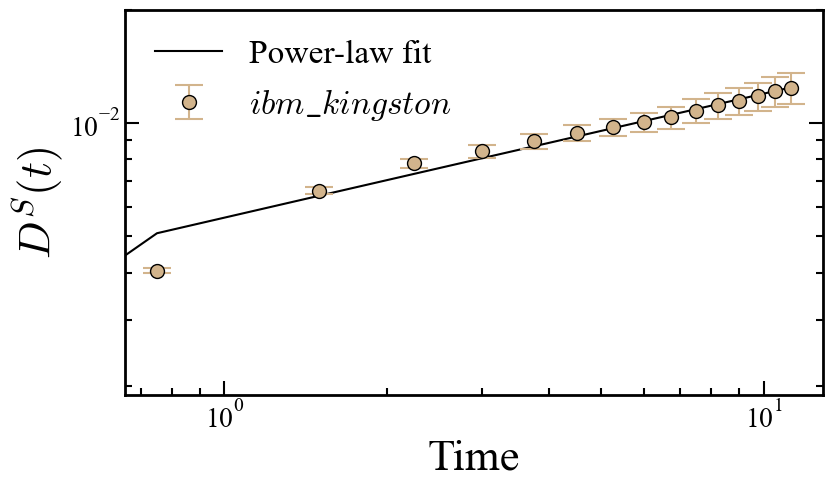

In [16]:
times = np.arange(0, 0.75*16, 0.75)
D_t = np.zeros(shape=(100, 16))
data = odr_cjj_1
parameters_set = []
index = 0
# area = np.trapz(f, t) 
for i in range(100):
    local = [np.trapz(data[i,:j+1], times[:j+1]) for j in range(16)]
    D_t[i] = local 
    parameters, covariance = curve_fit(power, times[index:], local[index:])
    parameters_set.append(parameters)
parameters_set = np.array(parameters_set)


times = np.arange(0,0.75*(15+1),0.75)
fig, ax = plt.subplots(figsize=(9,5)) 
font25 = {'family': 'Times new roman','weight': 'normal','size': 18}
plt.rcParams['mathtext.fontset'] ='cm'  
ax.errorbar(times, np.mean(D_t, axis=0), yerr= 2*np.std(D_t, axis =0),
              color = 'tan', capsize=10, capthick= 1.5, fmt='o',label = '$ibm\_kingston$',
              markeredgecolor='black', zorder=15, markersize= 10)
ax.plot(times, power(times, np.mean(parameters_set[:,0]),
                    np.mean(parameters_set[:,1]),
                    np.mean(parameters_set[:,2])), color= 'black', label='Power-law fit')
ax.set_ylim(0.0019, 0.02)
adjust_ax(ax)
ax.set_xlabel('Time', font='Times new roman', fontsize=32)
ax.set_ylabel('$ D^S(t) $',  font='Times new roman', fontsize=32)
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(prop=font1, frameon=False, ncol=1, )
print(np.mean(parameters_set[:,1]))
print(np.std(parameters_set[:,1]))

8.108847655279222e-09
7.663648414068928e-09


/var/folders/jt/xv4mn94150s9b4bx13g2y61w0000gp/T/ipykernel_57484/3258957459.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  local = [np.trapz(data[i,:j+1], times[:j+1]) for j in range(16)]
/var/folders/jt/xv4mn94150s9b4bx13g2y61w0000gp/T/ipykernel_57484/3258957459.py:4: RuntimeWarning: divide by zero encountered in power
  y = (x)**(alpha)+C
/var/folders/jt/xv4mn94150s9b4bx13g2y61w0000gp/T/ipykernel_57484/3258957459.py:15: OptimizeWarning: Covariance of the parameters could not be estimated
  parameters, covariance = curve_fit(power_d, times, local)


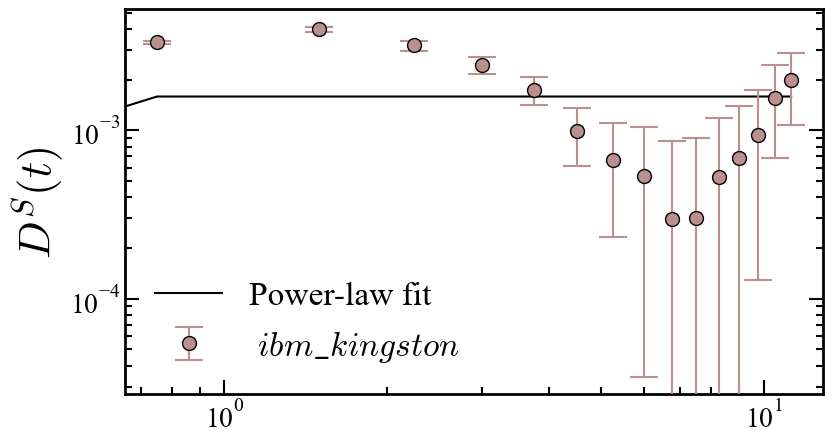

In [17]:
from scipy.optimize import curve_fit

def power_d(x, alpha, C):
    y = (x)**(alpha)+C
    return y

times = np.arange(0, 0.75*16, 0.75)
D_t = np.zeros(shape=(100, 16))
data = odr_cjj_16
parameters_set = []

for i in range(100):
    local = [np.trapz(data[i,:j+1], times[:j+1]) for j in range(16)]
    D_t[i] = local
    parameters, covariance = curve_fit(power_d, times, local)
    parameters_set.append(parameters)
parameters_set = np.array(parameters_set)

times = np.arange(0,0.75*(15+1),0.75)
fig, ax = plt.subplots(figsize=(9,5)) 
font25 = {'family': 'Times new roman','weight': 'normal','size': 18}
plt.rcParams['mathtext.fontset'] ='cm'  

ax.errorbar(times, np.mean(D_t, axis=0), yerr= 2*np.std(D_t, axis =0),
              color = 'rosybrown', capsize=10, capthick= 1.5, fmt='o',label = ' $ibm\_kingston$',
              markeredgecolor='black', zorder=15, markersize= 10)
ax.plot(times, power_d(times, np.mean(parameters_set[:,0]),
                    np.mean(parameters_set[:,1]))/40, color= 'black', label='Power-law fit')
adjust_ax(ax)
ax.set_ylabel('$ D^S(t) $',  font='Times new roman', fontsize=32)
ax.legend(prop=font1, frameon=False, ncol=1, )
print(np.mean(parameters_set[:,0]))
print(np.std(parameters_set[:,0]))
ax.set_xscale('log')
ax.set_yscale('log')
